<a href="https://colab.research.google.com/github/Gada-23/Ambo-University-Online-Exam-System/blob/main/model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Check GPU
import tensorflow as tf
print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)


TF version: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [12]:
import tensorflow as tf

# Path to your dataset in Google Drive
dataset_path = "/content/drive/MyDrive/ethiopian_birr_dataset"

# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'  # labels as integers (0–4)
)

# Load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path + "/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'
)

# Check class names
print("Classes:", train_ds.class_names,val_ds.class_names)


Found 1035 files belonging to 5 classes.
Found 295 files belonging to 5 classes.
Classes: ['100birr', '10birr', '200birr', '50birr', '5birr'] ['100birr', '10birr', '200birr', '50birr', '5birr']


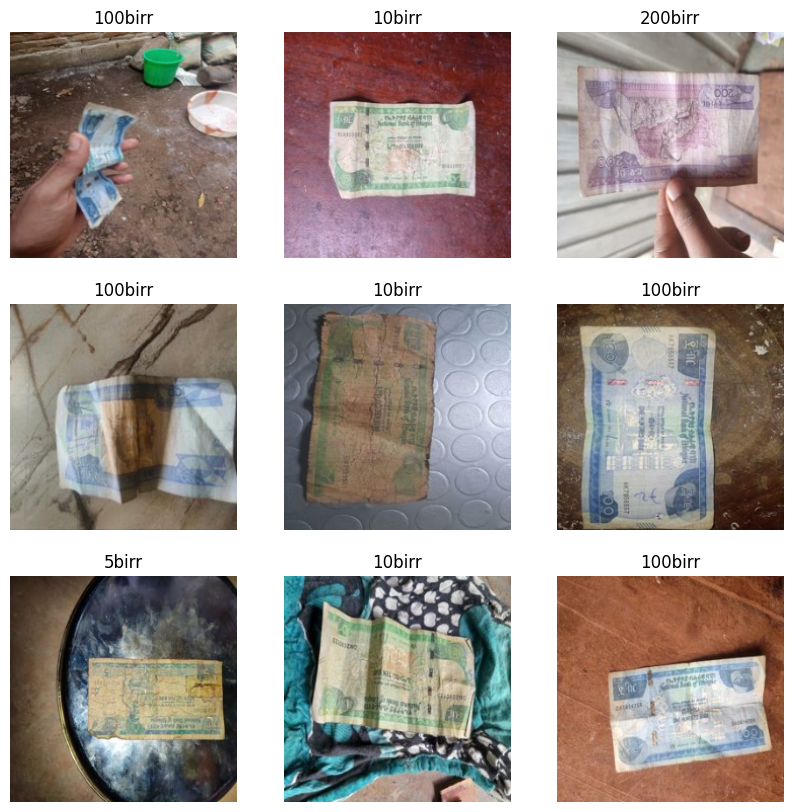

In [5]:
import matplotlib.pyplot as plt

# Get one batch of images and labels
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):  # show 9 sample images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

# Improve performance by prefetching and caching
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Dataset ready for training!")


✅ Dataset ready for training!


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

# Number of classes (5 birr denominations)
num_classes = 5

# Load pretrained MobileNetV2 without the top layer
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base model initially

# Build the new model on top
inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,   # you can increase later to 15–20
    verbose=1
)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.1678 - loss: 2.0396 - val_accuracy: 0.2102 - val_loss: 1.8223
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2335 - loss: 1.8838 - val_accuracy: 0.2610 - val_loss: 1.7062
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2882 - loss: 1.7757 - val_accuracy: 0.3220 - val_loss: 1.6028
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3137 - loss: 1.6721 - val_accuracy: 0.3695 - val_loss: 1.5059
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3657 - loss: 1.5751 - val_accuracy: 0.4203 - val_loss: 1.4233
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4153 - loss: 1.4395 - val_accuracy: 0.4542 - val_loss: 1.3472
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4386 - loss: 1.3945 - val_accuracy: 0.4983 - val_loss: 1.2799
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4973 - loss: 1.2978 - val_accuracy: 0.5356 - v

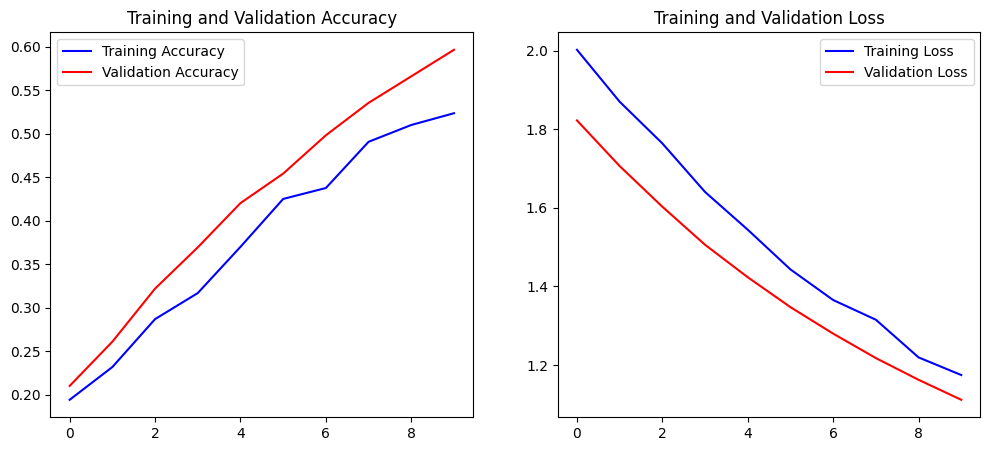

In [9]:
import matplotlib.pyplot as plt

# Plot accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [10]:
# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Optionally, freeze the first few layers (keep low-level features)
for layer in base_model.layers[:-40]:  # tune only top 40 layers
    layer.trainable = False

# Recompile with a smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the model
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # you can increase if accuracy keeps improving
    verbose=1
)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 621ms/step - accuracy: 0.4612 - loss: 1.3076 - val_accuracy: 0.6610 - val_loss: 0.9785
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6037 - loss: 1.0372 - val_accuracy: 0.7288 - val_loss: 0.8747
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7135 - loss: 0.8493 - val_accuracy: 0.7695 - val_loss: 0.7817
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8173 - loss: 0.6713 - val_accuracy: 0.8034 - val_loss: 0.7027
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8393 - loss: 0.5802 - val_accuracy: 0.8407 - val_loss: 0.6349
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9047 - loss: 0.4605 - val_accuracy: 0.8475 - val_loss: 0.5806
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9287 - loss: 0.3896 - val_accuracy: 0.8542 - val_loss: 0.5311
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9204 - loss: 0.3566 - val_accuracy: 0.8678 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


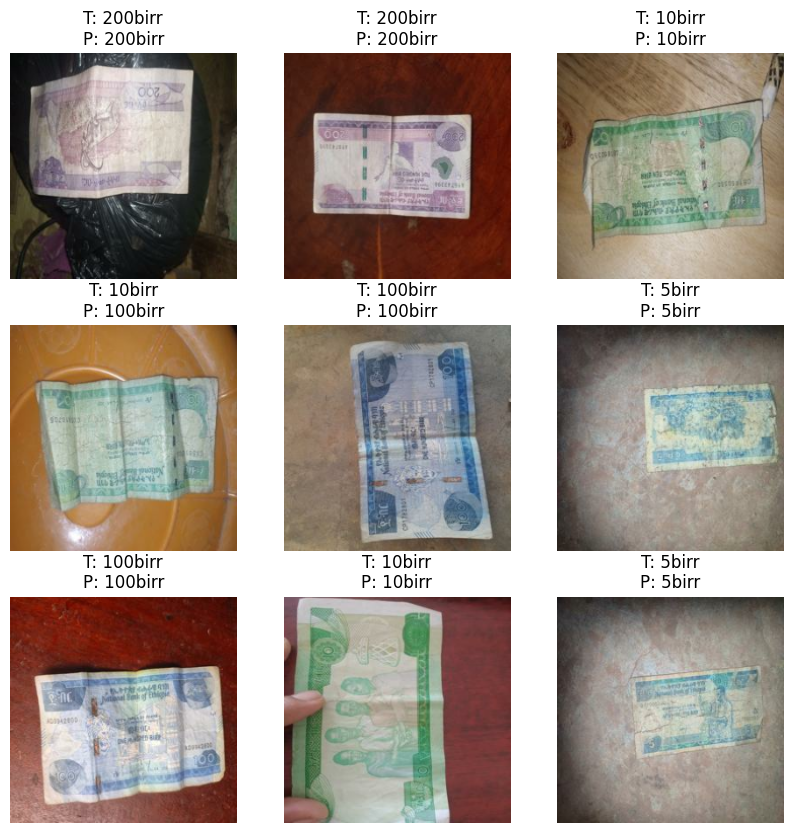

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Get one batch from validation dataset
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))
    for i in range(9):  # Show 9 predictions
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = val_ds.class_names[labels[i]]
        predicted_label = val_ds.class_names[pred_labels[i]]
        plt.title(f"T: {true_label}\nP: {predicted_label}")
        plt.axis("off")
